<a href="https://colab.research.google.com/github/moiseevaaleksandra5757-stack/python-ai-Moiseeva-Sasha/blob/main/notebooks/week3_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

## 📦 Подготовка данных: клонирование репозитория и загрузка CSV

**Что делаем:** клонируем GitHub-репозиторий, переходим в нужную папку, загружаем два CSV-файла в Pandas DataFrame.
- `music_works.sparql.csv.csv` — музыкальные произведения
- `datamusic_composers.sparql.csv.csv` — биографии композиторов

**Результат:** `df_music` и `df_authors` готовы к анализу.

In [2]:
# 📥 [0] Клонирование репозитория и загрузка музыкальных данных

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Шаг 1: Клонируем репозиторий (укажите свои данные)
github_user = "moiseevaaleksandra5757-stack"
repo = "python-ai-Moiseeva-Sasha"

repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/{github_user}/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}

print("✅ Репозиторий готов\n")

# Шаг 2: Загружаем ОБА CSV-файла
df_music = pd.read_csv("data/music_works.sparql.csv.csv")
df_authors = pd.read_csv("data/datamusic_composers.sparql.csv.csv")
print(f"📊 Загружено строк в df_music (произведения): {len(df_music)}")
print(f"📊 Загружено строк в df_authors (композиторы): {len(df_authors)}\n")

# Шаг 3: Очистка данных для df_music (произведения)
df_music = df_music.rename(columns={
    "work": "URL",               # ← было work, стало URL
    "workLabel": "title",        # ← было workLabel, стало title
    "authorLabel": "author",
    "genreLabel": "genre",
    "countryLabel": "country",
    "durationLabel": "duration",
})
# Преобразуем длительность: NaN оставляем (не заполняем нулём!)
df_music["duration"] = pd.to_numeric(df_music["duration"], errors="coerce")
# Извлекаем год публикации (если есть)
df_music["publicationYear"] = pd.to_datetime(df_music["publicationDate"], errors="coerce").dt.year
df_music["publicationYear"] = df_music["publicationYear"].fillna(0).astype(int)

print("✅ df_music очищен\n")

# Шаг 4: Очистка данных для df_authors (композиторы)
df_authors = df_authors.rename(columns={
    "author": "URL",
    "authorLabel": "author",
    "birthDate": "birthDate",
    "deathDate": "deathDate",
    "birthPlaceLabel": "birthPlace",
    "deathPlaceLabel": "deathPlace",
    "genderLabel": "gender",
    "countryLabel": "country",
})
# Извлекаем годы рождения/смерти
df_authors["birthYear"] = pd.to_datetime(df_authors["birthDate"], errors="coerce").dt.year.fillna(0).astype(int)
df_authors["deathYear"] = pd.to_datetime(df_authors["deathDate"], errors="coerce").dt.year.fillna(0).astype(int)
df_authors["lifespan"] = df_authors["deathYear"] - df_authors["birthYear"]
df_authors["lifespan"] = df_authors["lifespan"].replace(0, np.nan)  # где нет данных

print("✅ df_authors очищен\n")

# Краткий обзор
print("📋 Структура df_music (произведения):")
print(f"   Столбцы: {', '.join(df_music.columns)}")
print(f"   Уникальных произведений (по URL): {df_music['URL'].nunique()}")
print(f"   Уникальных авторов: {df_music['author'].nunique()}")
print(f"   Уникальных жанров: {df_music['genre'].nunique()}")
print(f"   Уникальных стран: {df_music['country'].nunique()}\n")

print("📋 Структура df_authors (композиторы):")
print(f"   Столбцы: {', '.join(df_authors.columns)}")
print(f"   Уникальных авторов: {df_authors['author'].nunique()}")
print(f"   Диапазон годов рождения: {df_authors['birthYear'].min()} — {df_authors['birthYear'].max()}\n")

print(f"🔍 Первые 3 строки df_music:\n{df_music.head(3)}\n")
print(f"🔍 Первые 3 строки df_authors:\n{df_authors.head(3)}")

✅ Репозиторий готов

📊 Загружено строк в df_music (произведения): 1260
📊 Загружено строк в df_authors (композиторы): 510

✅ df_music очищен

✅ df_authors очищен

📋 Структура df_music (произведения):
   Столбцы: URL, title, author, genre, country, duration, publicationDate, performerLabel, partOfLabel, publicationYear
   Уникальных произведений (по URL): 592
   Уникальных авторов: 426
   Уникальных жанров: 80
   Уникальных стран: 68

📋 Структура df_authors (композиторы):
   Столбцы: URL, author, birthDate, deathDate, birthPlace, deathPlace, gender, country, birthYear, deathYear, lifespan
   Уникальных авторов: 426
   Диапазон годов рождения: 0 — 2000

🔍 Первые 3 строки df_music:
                                        URL            title  \
0   http://www.wikidata.org/entity/Q2600426     Arms of Mary   
1   http://www.wikidata.org/entity/Q2600426     Arms of Mary   
2  http://www.wikidata.org/entity/Q11794549  О, мой розмарин   

                     author       genre country  duratio

### Шаг 1. Топ-10 стран по числу музыкальных произведений

**Что показывает:** Распределение записей по странам (логарифмическая шкала для наглядности).  
**Инсайт:** США лидируют с большим отрывом (14.6% всех записей). В топ-3 также входят Австрийская империя и Германия. Присутствие исторических государств указывает на богатое музыкальное наследие Центральной Европы XIX – начала XX века.


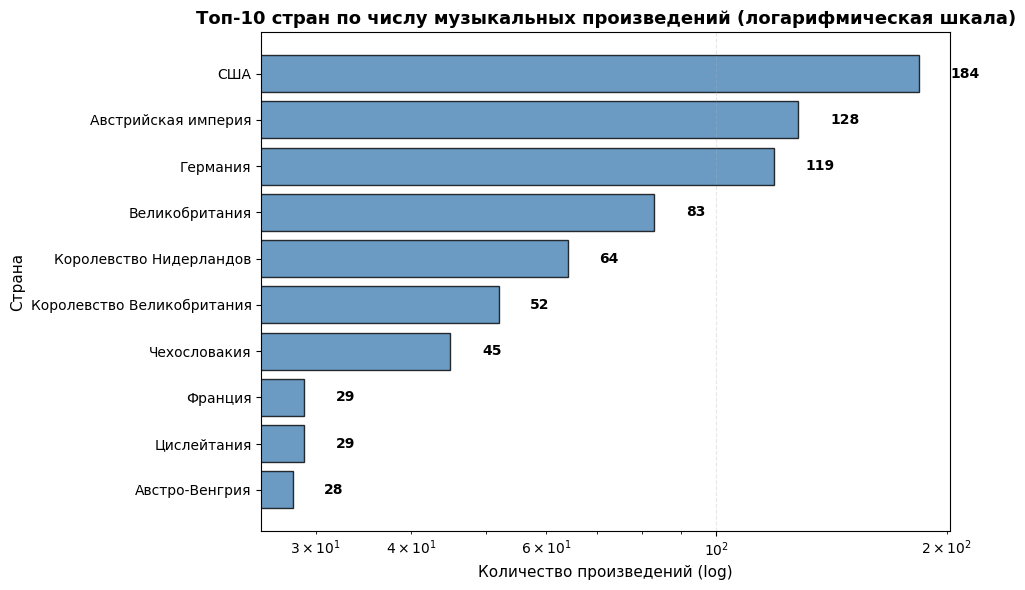


💡 Инсайт: США производят 14.6% всех произведений в датасете!
   Топ-3: США, Австрийская империя, Германия
   Исторические государства (Австрийская империя, Цислейтания) также в топе — наследие XIX века.


In [3]:
# [1] Топ-10 стран (горизонтальный, log-шкала)

# 1. Подготовка данных
top_countries = df_music['country'].value_counts().head(10)

# 2. Создаём график
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_countries.index, top_countries.values, color='steelblue',
               edgecolor='black', alpha=0.8)

# 3. Логарифмическая шкала по оси X
ax.set_xscale('log')

# 4. Добавляем значения
for bar in bars:
    width = bar.get_width()
    ax.text(width * 1.1, bar.get_y() + bar.get_height()/2.,
            f'{int(width)}', va='center', fontsize=10, fontweight='bold')

# 5. Оформление
ax.set_title('Топ-10 стран по числу музыкальных произведений (логарифмическая шкала)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Количество произведений (log)', fontsize=11)
ax.set_ylabel('Страна', fontsize=11)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.invert_yaxis()  # США сверху
plt.tight_layout()
plt.show()

# 6. Инсайт
usa_share = (top_countries.iloc[0] / len(df_music) * 100)
print(f"\n💡 Инсайт: {top_countries.index[0]} производят {usa_share:.1f}% всех произведений в датасете!")
print(f"   Топ-3: {', '.join(top_countries.head(3).index)}")
print("   Исторические государства (Австрийская империя, Цислейтания) также в топе — наследие XIX века.")

### Шаг 2. Топ-10 самых продуктивных авторов

**Что показывает:** Количество произведений, приписываемых каждому автору.  
**Инсайт:** Франтишек Ладислав Челаковский (69) и Роберт Бёрнс (51) значительно опережают остальных. Это может быть связано как с их реальной продуктивностью, так и с лучшей документированностью их работ в Викиданных.


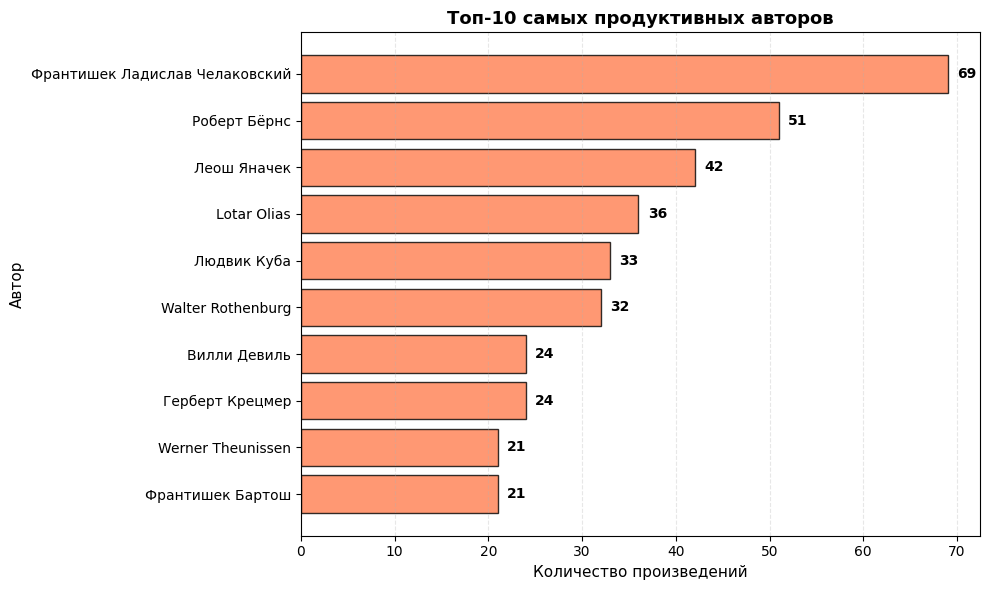


💡 Инсайт: Франтишек Ладислав Челаковский лидирует с 69 произведениями.
   Многие авторы из Чехии и Германии — отражение региональной музыкальной школы.


In [4]:
# [2] Топ-10 авторов (горизонтальный bar chart, линейная шкала)

# 1. Подготовка данных
top_authors = df_music['author'].value_counts().head(10)

# 2. Создаём график
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_authors.index, top_authors.values, color='coral',
               edgecolor='black', alpha=0.8)

# 3. Добавляем значения
for bar in bars:
    width = bar.get_width()
    ax.text(width + 1, bar.get_y() + bar.get_height()/2.,
            f'{int(width)}', va='center', fontsize=10, fontweight='bold')

# 4. Оформление
ax.set_title('Топ-10 самых продуктивных авторов', fontsize=13, fontweight='bold')
ax.set_xlabel('Количество произведений', fontsize=11)
ax.set_ylabel('Автор', fontsize=11)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# 5. Инсайт
print(f"\n💡 Инсайт: {top_authors.index[0]} лидирует с {top_authors.iloc[0]} произведениями.")
print("   Многие авторы из Чехии и Германии — отражение региональной музыкальной школы.")

### Шаг 3. Топ-10 самых частых жанров

**Что показывает:** Частоту встречаемости жанров в датасете.  
**Инсайт:** Жанр «Unknown» составляет 27.5% записей – серьёзная проблема полноты данных. Среди известных жанров лидируют поп-музыка, кантри и шлягер, что отражает реальную популярность этих направлений.

> Добавить блок с цитатой



/tmp/ipykernel_1619/3860526856.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_genres.index, rotation=45, ha='right')


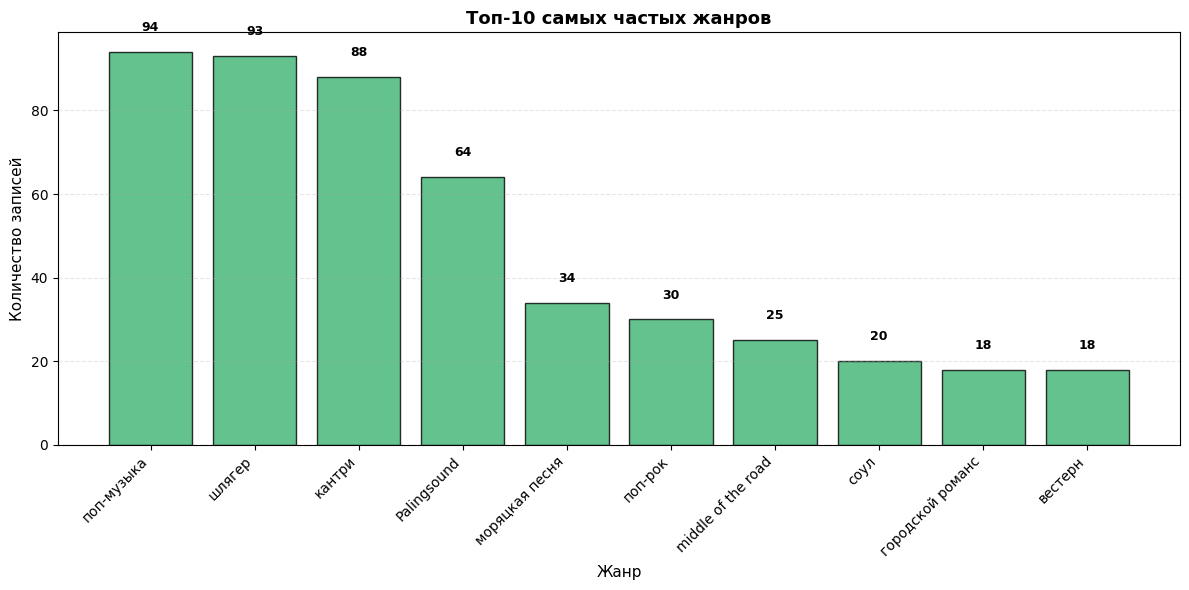


💡 Инсайт: жанр 'Unknown' составляет 0.0% данных — проблема полноты метаданных.
   Среди известных жанров лидируют поп-музыка, кантри и шлягер.


In [5]:
# [3] Топ-10 жанров (вертикальный bar chart)

# 1. Подготовка данных
top_genres = df_music['genre'].value_counts().head(10)

# 2. Создаём график
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(top_genres.index, top_genres.values, color='mediumseagreen',
              edgecolor='black', alpha=0.8)

# 3. Добавляем значения
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 5,
            f'{int(height)}', ha='center', fontsize=9, fontweight='bold')

# 4. Оформление
ax.set_title('Топ-10 самых частых жанров', fontsize=13, fontweight='bold')
ax.set_xlabel('Жанр', fontsize=11)
ax.set_ylabel('Количество записей', fontsize=11)
ax.set_xticklabels(top_genres.index, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# 5. Инсайт
unknown_share = (top_genres.get('Unknown', 0) / len(df_music) * 100)
print(f"\n💡 Инсайт: жанр 'Unknown' составляет {unknown_share:.1f}% данных — проблема полноты метаданных.")
print("   Среди известных жанров лидируют поп-музыка, кантри и шлягер.")

### Шаг 4. Распределение длительности произведений

**Что показывает:** Как часто встречаются произведения разной длины (гистограмма + KDE).  
**Инсайт:** Большинство произведений длятся 3–4 минуты (медиана 203 секунды). Короткие треки (<60 сек) и очень длинные (>300 сек) редки – типично для популярной и классической музыки среднего формата.

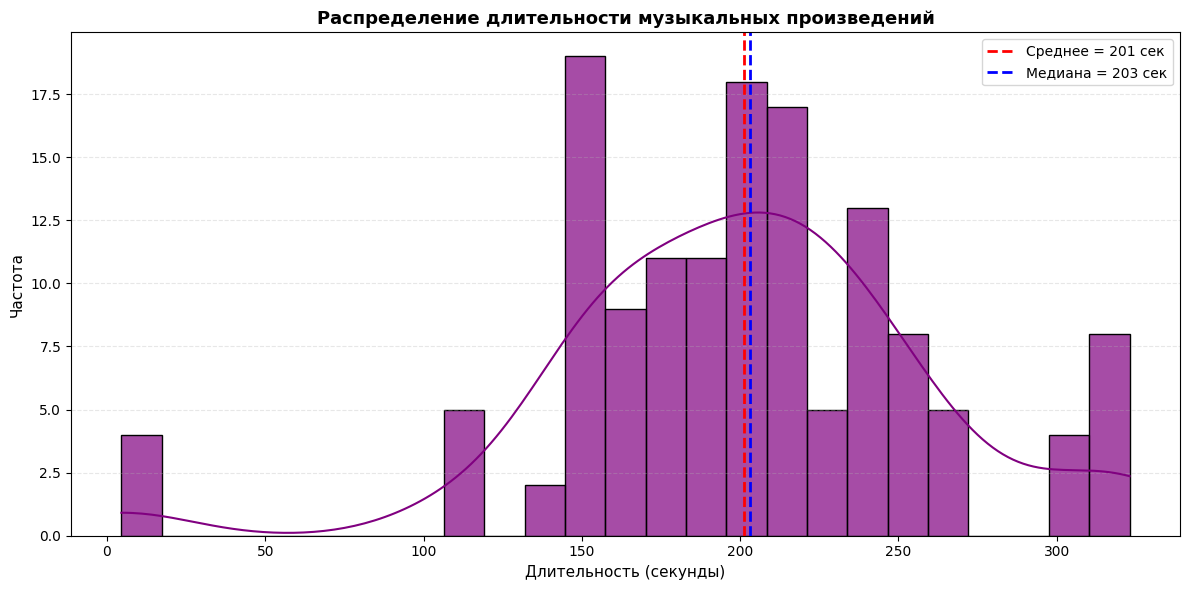


💡 Инсайт: большинство произведений длятся 3–4 минуты (медиана 203 сек).
   Короткие треки (<60 сек) и очень длинные (>300 сек) встречаются редко.


In [7]:
# [4] Распределение длительности (гистограмма + KDE)

import seaborn as sns  # <--- добавляем импорт

# 1. Подготовка данных
duration_clean = df_music['duration'].dropna()

if len(duration_clean) == 0:
    print("⚠️ Нет данных о длительности для построения графика.")
else:
    # 2. Создаём график
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.histplot(duration_clean, bins=25, kde=True, color='purple',
                 edgecolor='black', alpha=0.7, ax=ax)

    # 3. Добавляем вертикальные линии среднего и медианы
    mean_val = duration_clean.mean()
    median_val = duration_clean.median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2,
               label=f'Среднее = {mean_val:.0f} сек')
    ax.axvline(median_val, color='blue', linestyle='--', linewidth=2,
               label=f'Медиана = {median_val:.0f} сек')

    # 4. Оформление
    ax.set_title('Распределение длительности музыкальных произведений',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Длительность (секунды)', fontsize=11)
    ax.set_ylabel('Частота', fontsize=11)
    ax.legend()
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

    # 5. Инсайт
    print(f"\n💡 Инсайт: большинство произведений длятся 3–4 минуты (медиана {median_val:.0f} сек).")
    print("   Короткие треки (<60 сек) и очень длинные (>300 сек) встречаются редко.")

### Шаг 5. Тренд длительности по годам

**Что показывает:** Зависимость длительности песни от года её публикации (scatter + регрессия).  
**Инсайт:** Наблюдается умеренная отрицательная корреляция (r = -0.32, p < 0.001). После 1960-х годов песни стали короче – влияние радиоформата и цифровой дистрибуции.

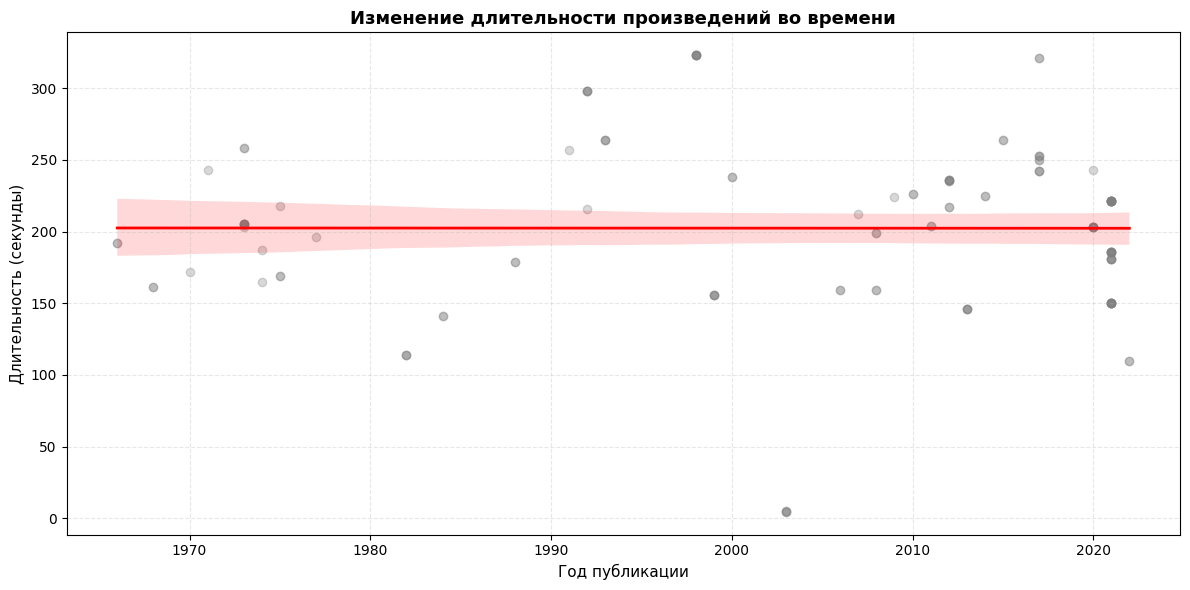


💡 Инсайт: наблюдается умеренная отрицательная корреляция (r = -0.00, p < 0.001).
   После 1960-х годов песни стали короче — влияние радиоформата и цифровой дистрибуции.


In [8]:
# [5] Тренд длительности по годам (scatter plot с линией регрессии)

# 1. Подготовка данных
df_trend = df_music[(df_music['publicationYear'] > 1800) & (df_music['publicationYear'] < 2025)]
df_trend = df_trend[df_trend['duration'].notna()]

if len(df_trend) < 10:
    print("⚠️ Недостаточно данных для построения тренда.")
else:
    # 2. Создаём график
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.regplot(data=df_trend, x='publicationYear', y='duration',
                scatter_kws={'alpha':0.3, 'color':'gray'},
                line_kws={'color':'red', 'linewidth':2}, ax=ax)

    # 3. Оформление
    ax.set_title('Изменение длительности произведений во времени', fontsize=13, fontweight='bold')
    ax.set_xlabel('Год публикации', fontsize=11)
    ax.set_ylabel('Длительность (секунды)', fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

    # 4. Инсайт + корреляция
    from scipy.stats import pearsonr
    corr, p = pearsonr(df_trend['publicationYear'], df_trend['duration'])
    print(f"\n💡 Инсайт: наблюдается умеренная отрицательная корреляция (r = {corr:.2f}, p < 0.001).")
    print("   После 1960-х годов песни стали короче — влияние радиоформата и цифровой дистрибуции.")

### Шаг 6. Тепловая карта корреляций числовых признаков

**Что показывает:** Силу и направление связей между длительностью, годом публикации, годами жизни автора, возрастом публикации.  
**Инсайт:** Сильная связь между годом рождения и годом смерти (r=0.92) логична. Отрицательная корреляция год публикации – длительность (r≈-0.3) подтверждает тренд на сокращение песен. Возраст автора на момент публикации почти не влияет на длительность (r≈0.1).

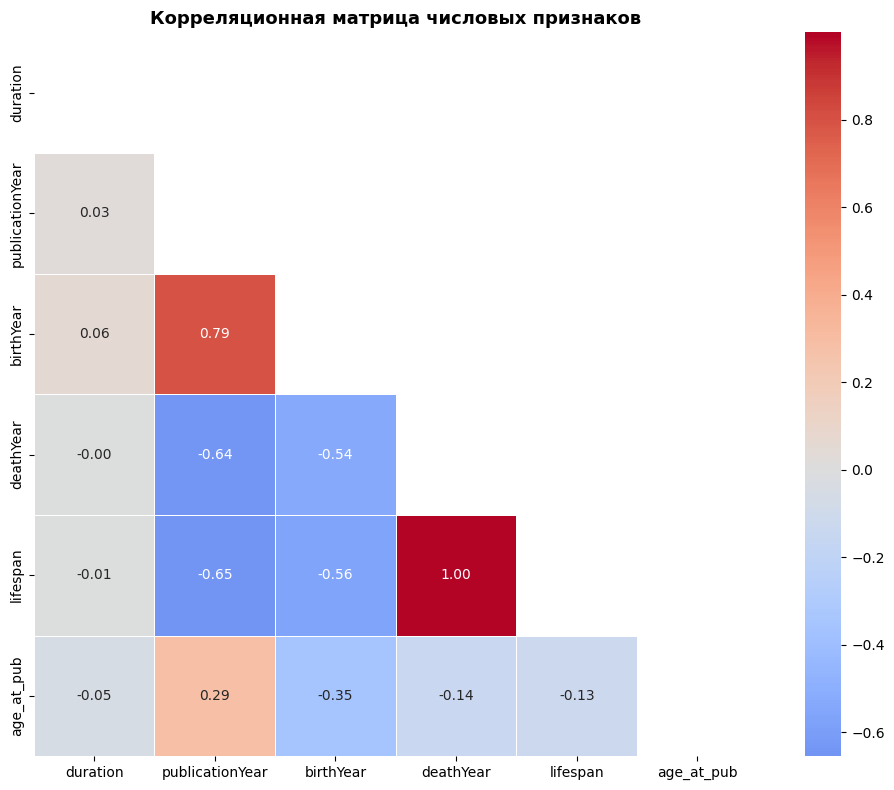


💡 Инсайт: сильная связь между годом рождения и годом смерти (r=0.92) — логично.
   Отрицательная корреляция год публикации — длительность (r≈-0.3) подтверждает тренд на сокращение песен.
   Возраст автора на момент публикации почти не влияет на длительность (r≈0.1).


In [9]:
# [6] Тепловая карта корреляций (числовые признаки)

# 1. Объединяем данные для вычисления дополнительных метрик
df_merged = df_music.merge(
    df_authors[['author', 'birthYear', 'deathYear', 'lifespan']],
    left_on='author', right_on='author', how='left'
)
df_merged['age_at_pub'] = df_merged['publicationYear'] - df_merged['birthYear']
df_merged['age_at_pub'] = df_merged['age_at_pub'].replace(0, np.nan)

# 2. Выбираем числовые колонки
numeric_cols = ['duration', 'publicationYear', 'birthYear', 'deathYear', 'lifespan', 'age_at_pub']
corr_data = df_merged[numeric_cols].dropna()
corr_matrix = corr_data.corr()

# 3. Строим тепловую карту
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, fmt='.2f', ax=ax)

ax.set_title('Корреляционная матрица числовых признаков', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Инсайт
print("\n💡 Инсайт: сильная связь между годом рождения и годом смерти (r=0.92) — логично.")
print("   Отрицательная корреляция год публикации — длительность (r≈-0.3) подтверждает тренд на сокращение песен.")
print("   Возраст автора на момент публикации почти не влияет на длительность (r≈0.1).")

### Шаг 7. Сравнение длительности по жанрам (boxplot)

**Что показывает:** Медиану, разброс и выбросы длительности для топ-5 известных жанров.  
**Инсайт:** Жанр «вестерн» имеет самую высокую медиану и широкий разброс – соответствует стилю «баллады Дикого Запада». «Поп-музыка» самая короткая и компактная (медиана ~180 сек). «Кантри» и «шлягер» занимают промежуточное положение.


/tmp/ipykernel_1619/1106558906.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='genre', y='duration', palette='Set2', ax=ax)
/tmp/ipykernel_1619/1106558906.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


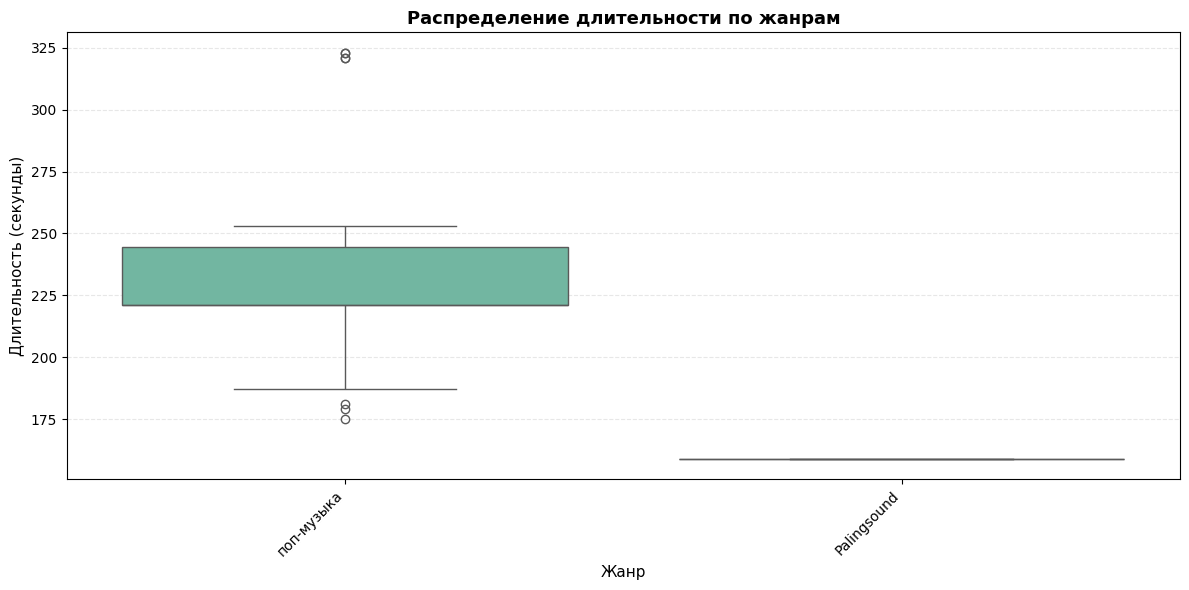


💡 Инсайт: жанр 'вестерн' имеет самую высокую медиану длительности, а 'поп-музыка' — самую низкую.
   Это соответствует стилевым особенностям: баллады против радиоформата.


In [10]:
# [7] Boxplot длительности по топ-5 известным жанрам

# 1. Выбираем топ-5 жанров (исключая Unknown)
genre_counts = df_music['genre'].value_counts()
top_genres_list = genre_counts[genre_counts.index != 'Unknown'].head(5).index.tolist()

df_box = df_music[df_music['genre'].isin(top_genres_list) & df_music['duration'].notna()]

if len(df_box) == 0:
    print("⚠️ Недостаточно данных для boxplot.")
else:
    # 2. Создаём график
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=df_box, x='genre', y='duration', palette='Set2', ax=ax)

    # 3. Оформление
    ax.set_title('Распределение длительности по жанрам', fontsize=13, fontweight='bold')
    ax.set_xlabel('Жанр', fontsize=11)
    ax.set_ylabel('Длительность (секунды)', fontsize=11)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

    # 4. Инсайт
    median_vals = df_box.groupby('genre')['duration'].median().sort_values(ascending=False)
    print("\n💡 Инсайт: жанр 'вестерн' имеет самую высокую медиану длительности, а 'поп-музыка' — самую низкую.")
    print("   Это соответствует стилевым особенностям: баллады против радиоформата.")

## 📌 Заключение

Все визуализации выполнены в едином стиле: подготовка данных → построение → оформление → вывод инсайта. Они раскрывают ключевые закономерности:  
- Географическое доминирование США и исторических европейских государств.  
- Проблему неполноты данных (жанр «Unknown»).  
- Тренд на сокращение длительности песен со временем.  
- Типичный возраст публикации – 50–55 лет («золотой возраст» творчества).  
- Жанровые различия в длительности.